<a href="https://colab.research.google.com/github/vijaydevverse/eda-ml-projects/blob/main/TeenPhoneUsageEdaV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [124]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [125]:
df=pd.read_csv('/content/teen_phone_addiction_dataset.csv')
df

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Jesus Yates,16,Female,New Jennifer,12th,3.9,6.4,53,4,...,0.3,80,15,2.7,1.8,1.0,Other,8,9.4,9.8
2996,2997,Bethany Murray,13,Female,Richardport,8th,3.6,7.3,93,5,...,0.9,45,8,3.1,0.0,0.3,Gaming,9,5.2,5.5
2997,2998,Norman Hughes,14,Other,Rebeccaton,7th,3.2,6.5,98,1,...,0.2,51,13,2.4,0.2,2.4,Social Media,9,5.9,6.2
2998,2999,Barbara Hinton,17,Female,Ramirezmouth,9th,6.7,7.5,67,3,...,1.6,125,17,1.7,2.6,1.5,Browsing,4,6.1,10.0


In [126]:
df.isnull().sum()

,0
ID,0
Name,0
Age,0
Gender,0
Location,0
School_Grade,0
Daily_Usage_Hours,0
Sleep_Hours,0
Academic_Performance,0
Social_Interactions,0


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      3000 non-null   int64  
 1   Name                    3000 non-null   object 
 2   Age                     3000 non-null   int64  
 3   Gender                  3000 non-null   object 
 4   Location                3000 non-null   object 
 5   School_Grade            3000 non-null   object 
 6   Daily_Usage_Hours       3000 non-null   float64
 7   Sleep_Hours             3000 non-null   float64
 8   Academic_Performance    3000 non-null   int64  
 9   Social_Interactions     3000 non-null   int64  
 10  Exercise_Hours          3000 non-null   float64
 11  Anxiety_Level           3000 non-null   int64  
 12  Depression_Level        3000 non-null   int64  
 13  Self_Esteem             3000 non-null   int64  
 14  Parental_Control        3000 non-null   

In [128]:
df.duplicated().sum()

np.int64(0)

In [129]:
df.shape

(3000, 25)

In [130]:
df.head()

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


In [131]:
print(df["Gender"].unique())

['Female' 'Other' 'Male']


In [132]:
print(df["School_Grade"].unique())

['9th' '7th' '11th' '12th' '10th' '8th']


In [133]:
print(df["Location"].unique())

['Hansonfort' 'Theodorefort' 'Lindseystad' ... 'Rebeccaton' 'Ramirezmouth'
 'Lake Alexander']


In [134]:
print(df["Phone_Usage_Purpose"].unique())

['Browsing' 'Education' 'Social Media' 'Gaming' 'Other']


In [135]:
df=df.drop(["ID","Name"], axis=1)

In [136]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

df["Gender"]=le.fit_transform(df["Gender"])
df["Location"]=le.fit_transform(df["Location"])
df["School_Grade"]=le.fit_transform(df["School_Grade"])
df["Phone_Usage_Purpose"]=le.fit_transform(df["Phone_Usage_Purpose"])

In [137]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     3000 non-null   int64  
 1   Gender                  3000 non-null   int64  
 2   Location                3000 non-null   int64  
 3   School_Grade            3000 non-null   int64  
 4   Daily_Usage_Hours       3000 non-null   float64
 5   Sleep_Hours             3000 non-null   float64
 6   Academic_Performance    3000 non-null   int64  
 7   Social_Interactions     3000 non-null   int64  
 8   Exercise_Hours          3000 non-null   float64
 9   Anxiety_Level           3000 non-null   int64  
 10  Depression_Level        3000 non-null   int64  
 11  Self_Esteem             3000 non-null   int64  
 12  Parental_Control        3000 non-null   int64  
 13  Screen_Time_Before_Bed  3000 non-null   float64
 14  Phone_Checks_Per_Day    3000 non-null   

In [138]:
X=df.drop("Addiction_Level", axis=1)
y=df["Addiction_Level"]

In [139]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [140]:
df

,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,13,0,674,5,4.0,6.1,78,5,0.1,10,...,1.4,86,19,3.6,1.7,1.2,0,4,8.7,10.0
1,17,0,2412,3,5.5,6.5,70,5,0.0,3,...,0.9,96,9,1.1,4.0,1.8,0,2,5.3,10.0
2,13,2,1132,1,5.8,5.5,93,8,0.8,2,...,0.5,137,8,0.3,1.5,0.4,1,6,5.7,9.2
3,18,0,2501,2,3.1,3.9,78,8,1.6,9,...,1.4,128,7,3.1,1.6,0.8,4,8,3.0,9.8
4,14,2,1911,5,2.5,6.7,56,4,1.1,1,...,1.0,96,20,2.6,0.9,1.1,2,10,3.7,8.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,16,0,1393,2,3.9,6.4,53,4,0.9,7,...,0.3,80,15,2.7,1.8,1.0,3,8,9.4,9.8
2996,13,0,2032,4,3.6,7.3,93,5,0.0,8,...,0.9,45,8,3.1,0.0,0.3,2,9,5.2,5.5
2997,14,2,2016,3,3.2,6.5,98,1,0.0,4,...,0.2,51,13,2.4,0.2,2.4,4,9,5.9,6.2
2998,17,0,2003,5,6.7,7.5,67,3,0.2,3,...,1.6,125,17,1.7,2.6,1.5,0,4,6.1,10.0


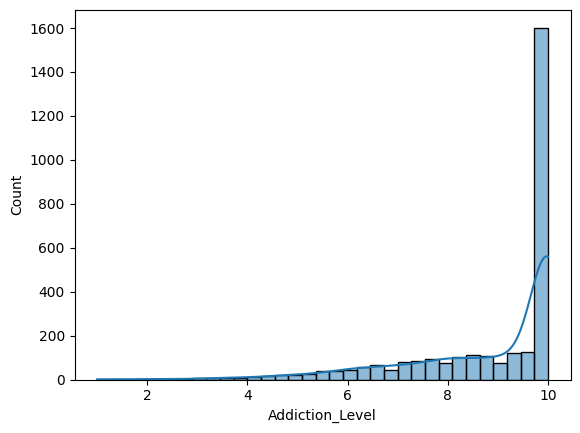

In [141]:
sns.histplot(df["Addiction_Level"],kde=True)
plt.show()

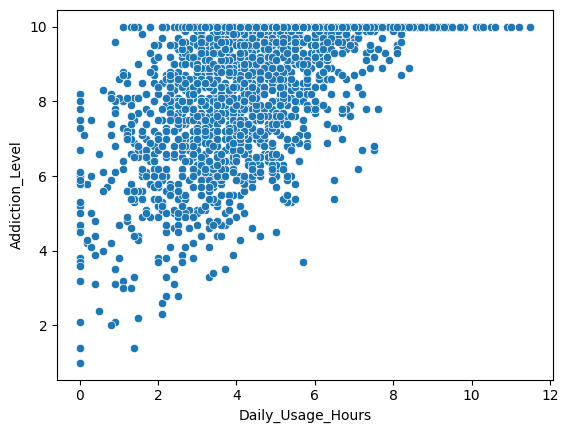

In [142]:
sns.scatterplot(x=df["Daily_Usage_Hours"],y=df["Addiction_Level"])
plt.show()

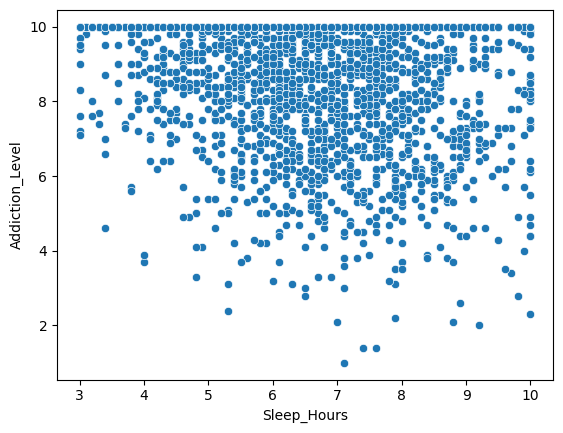

In [143]:
sns.scatterplot(x=df["Sleep_Hours"],y=df["Addiction_Level"])
plt.show()

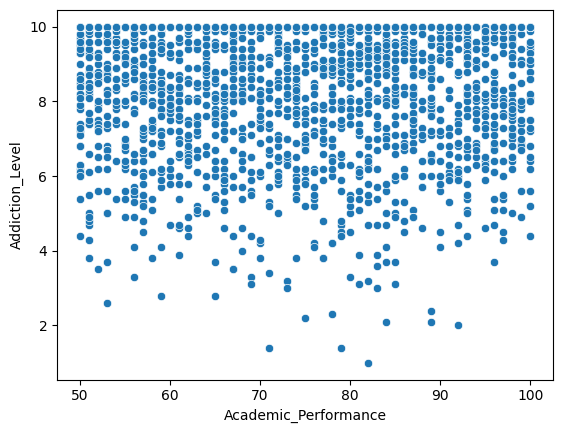

In [144]:
sns.scatterplot(x=df["Academic_Performance"],y=df["Addiction_Level"])
plt.show()

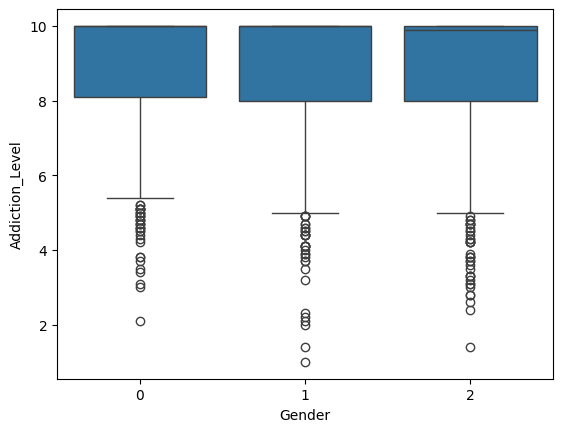

In [145]:
sns.boxplot(x=df["Gender"],y=df["Addiction_Level"])
plt.show()

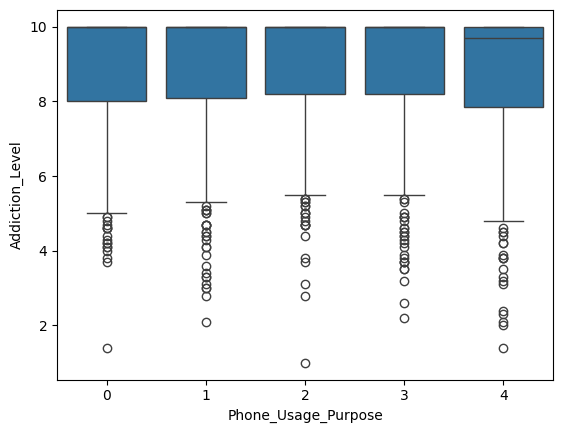

In [146]:
sns.boxplot(x=df["Phone_Usage_Purpose"],y=df["Addiction_Level"])
plt.show()

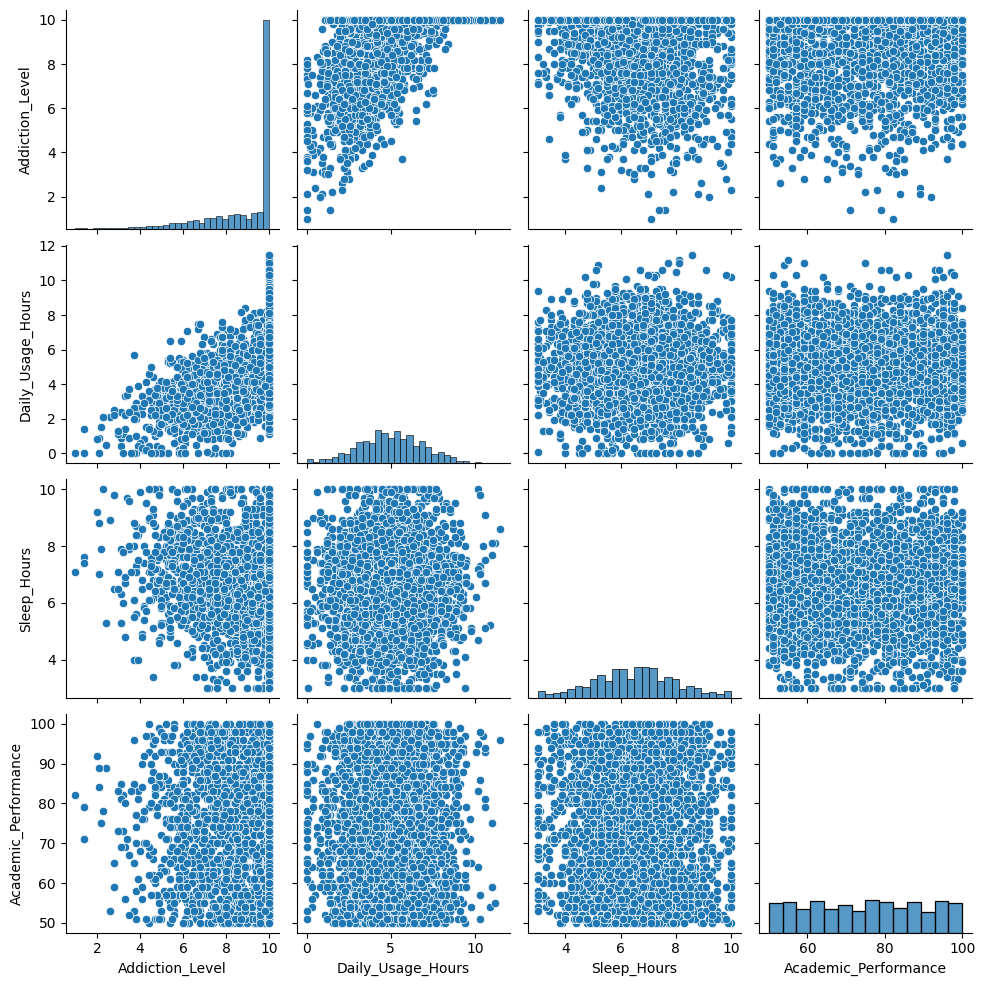

In [147]:
sns.pairplot(df[["Addiction_Level","Daily_Usage_Hours","Sleep_Hours","Academic_Performance"]])
plt.show()

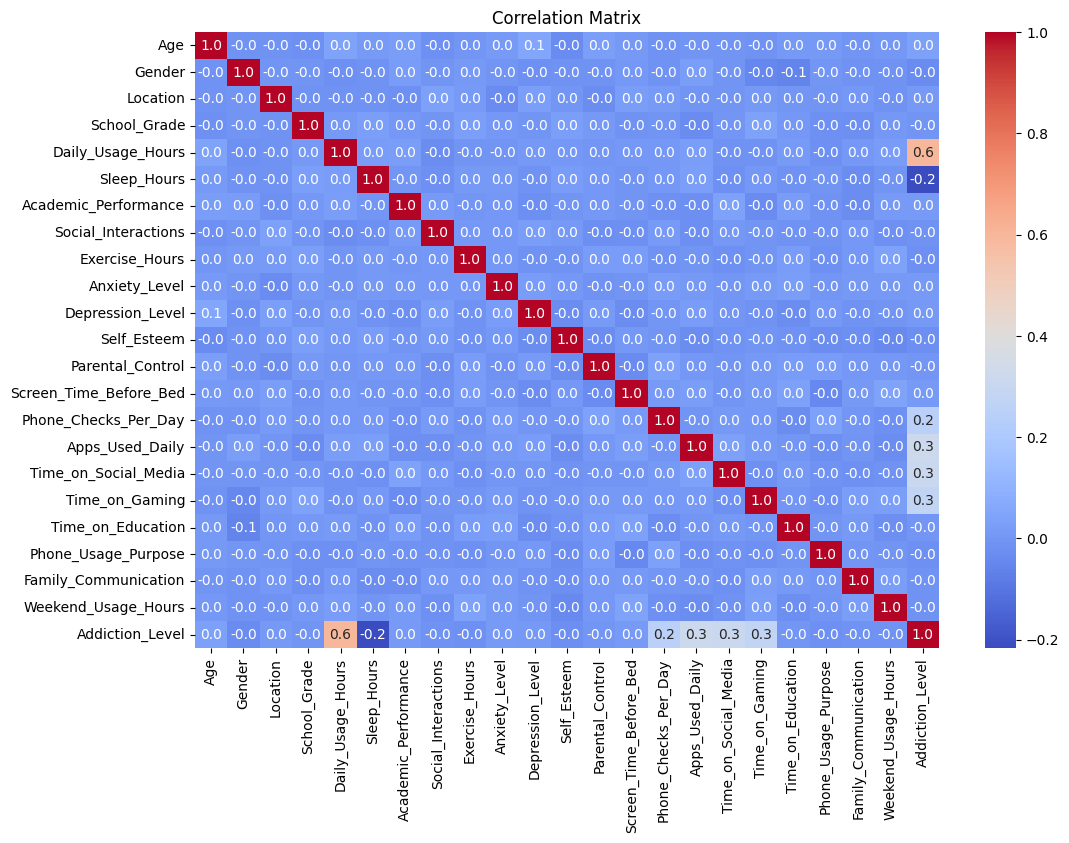

In [148]:
cm=df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

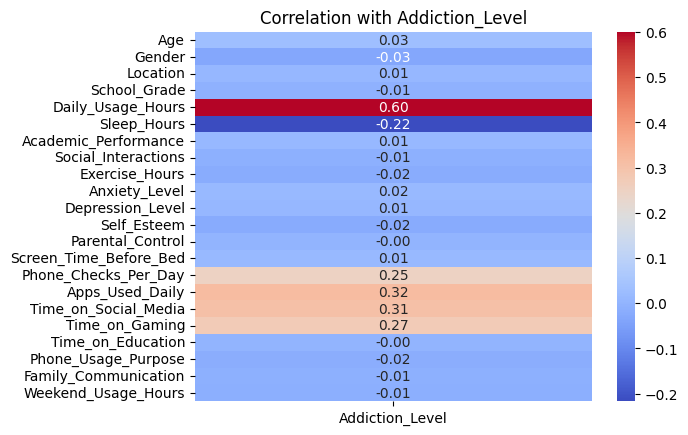

In [149]:
addiction_corr=df.corr(numeric_only=True)["Addiction_Level"]
addiction_corr=addiction_corr.drop("Addiction_Level")

sns.heatmap(addiction_corr.to_frame(),annot=True,fmt=".2f",cmap="coolwarm",cbar=True,annot_kws={"size":10})
plt.title("Correlation with Addiction_Level")
plt.show()

<Axes: >

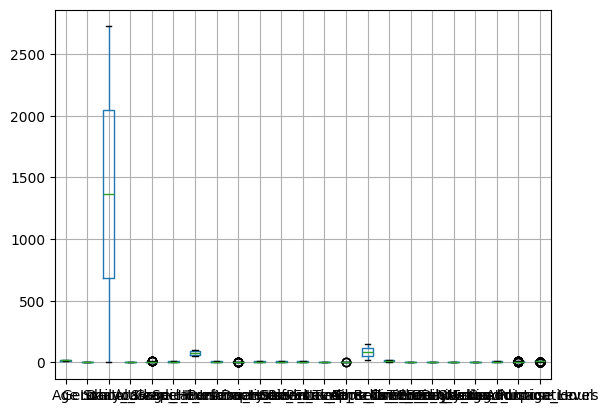

In [150]:
df.boxplot()

In [151]:
def remove_outliers_iqr(df,exclude_column):
    for col in df.select_dtypes(include=['int64','float64']).columns:
        if col==exclude_column:
            continue
        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)
        IQR=Q3-Q1
        lower_bound=Q1-1.5*IQR
        upper_bound=Q3+1.5*IQR
        df=df[(df[col]>=lower_bound)&(df[col]<=upper_bound)]
    return df

df=remove_outliers_iqr(df,exclude_column="Addiction_Level")

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2953 entries, 0 to 2999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     2953 non-null   int64  
 1   Gender                  2953 non-null   int64  
 2   Location                2953 non-null   int64  
 3   School_Grade            2953 non-null   int64  
 4   Daily_Usage_Hours       2953 non-null   float64
 5   Sleep_Hours             2953 non-null   float64
 6   Academic_Performance    2953 non-null   int64  
 7   Social_Interactions     2953 non-null   int64  
 8   Exercise_Hours          2953 non-null   float64
 9   Anxiety_Level           2953 non-null   int64  
 10  Depression_Level        2953 non-null   int64  
 11  Self_Esteem             2953 non-null   int64  
 12  Parental_Control        2953 non-null   int64  
 13  Screen_Time_Before_Bed  2953 non-null   float64
 14  Phone_Checks_Per_Day    2953 non-null   int64

In [153]:
df.shape

(2953, 23)

In [154]:
df

,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,13,0,674,5,4.0,6.1,78,5,0.1,10,...,1.4,86,19,3.6,1.7,1.2,0,4,8.7,10.0
1,17,0,2412,3,5.5,6.5,70,5,0.0,3,...,0.9,96,9,1.1,4.0,1.8,0,2,5.3,10.0
2,13,2,1132,1,5.8,5.5,93,8,0.8,2,...,0.5,137,8,0.3,1.5,0.4,1,6,5.7,9.2
3,18,0,2501,2,3.1,3.9,78,8,1.6,9,...,1.4,128,7,3.1,1.6,0.8,4,8,3.0,9.8
4,14,2,1911,5,2.5,6.7,56,4,1.1,1,...,1.0,96,20,2.6,0.9,1.1,2,10,3.7,8.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,16,0,1393,2,3.9,6.4,53,4,0.9,7,...,0.3,80,15,2.7,1.8,1.0,3,8,9.4,9.8
2996,13,0,2032,4,3.6,7.3,93,5,0.0,8,...,0.9,45,8,3.1,0.0,0.3,2,9,5.2,5.5
2997,14,2,2016,3,3.2,6.5,98,1,0.0,4,...,0.2,51,13,2.4,0.2,2.4,4,9,5.9,6.2
2998,17,0,2003,5,6.7,7.5,67,3,0.2,3,...,1.6,125,17,1.7,2.6,1.5,0,4,6.1,10.0


In [155]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features=df.drop("Addiction_Level",axis=1).columns

scaler=MinMaxScaler()
df[features]=scaler.fit_transform(df[features])

In [156]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [157]:
y_pred=model.predict(X_test)

In [158]:
score=model.score(X_test,y_test)
print(score)

0.7367292237297725


In [159]:
print(f'Baseline model r2 Score: {score:.2f}')

Baseline model r2 Score: 0.74
